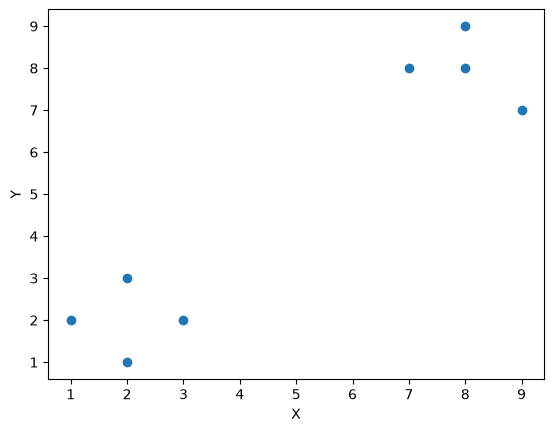

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],

    [8, 8],
    [9, 7],
    [8, 9],
    [7, 8]
])

plt.scatter(X[:, 0], X[:,1])

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

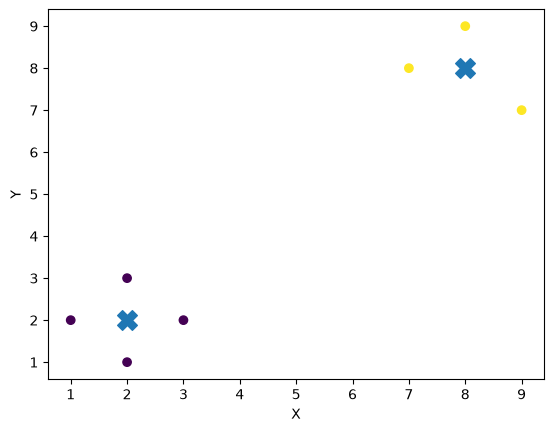

In [4]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=2,
    random_state=42
)

model.fit(X)

labels = model.labels_

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

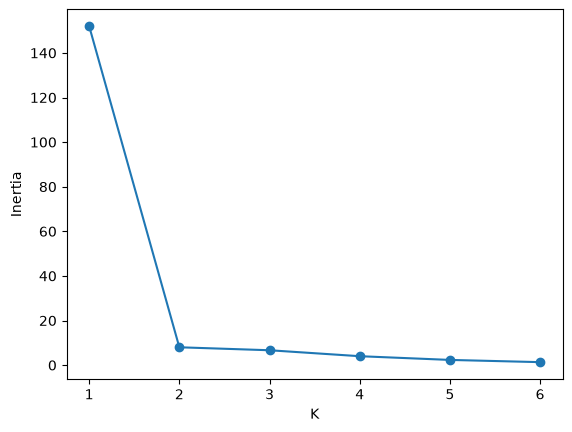

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],

    [8, 8],
    [9, 7],
    [8, 9],
    [7, 8]
])

inertia = []

for k in range(1, 7) :
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(
    range(1, 7),
    inertia,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Inertia")

plt.show()

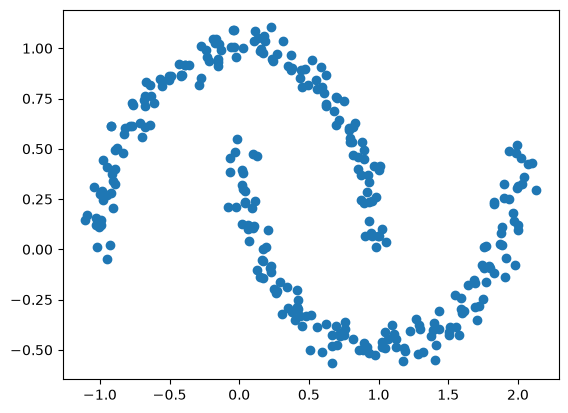

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)


plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.show()

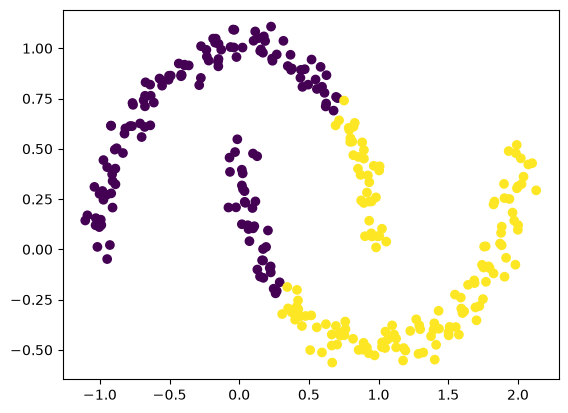

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

model = KMeans(
    n_clusters=2,
    random_state=42
)

labels = model.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.show()

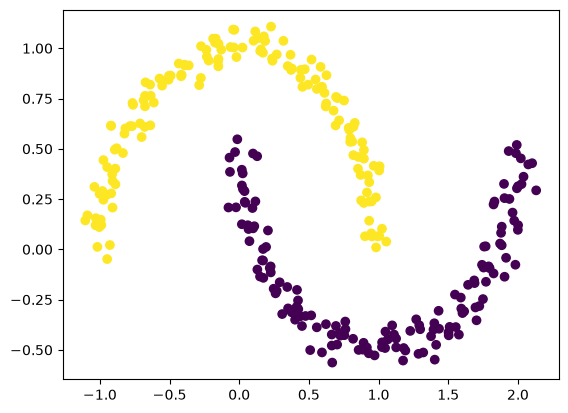

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

model = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = model.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.show()

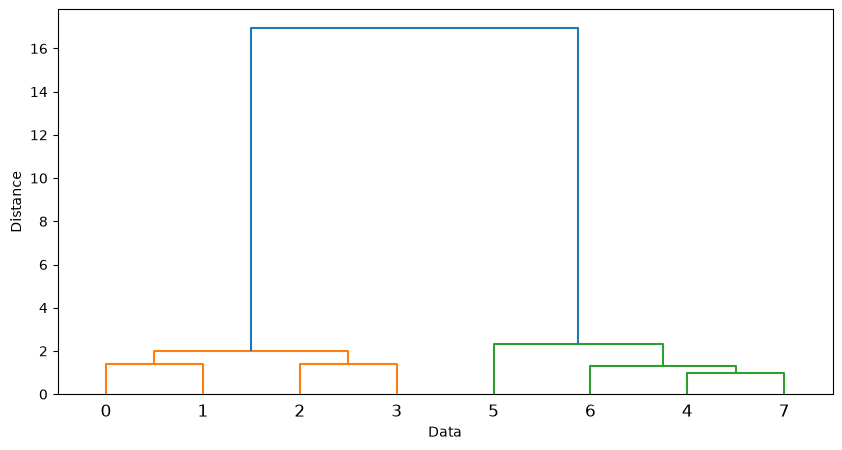

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],

    [8, 8],
    [9, 7],
    [8, 9],
    [7, 8]
])

linked = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(10, 5))

dendrogram(linked)

plt.xlabel("Data")
plt.ylabel("Distance")

plt.show()

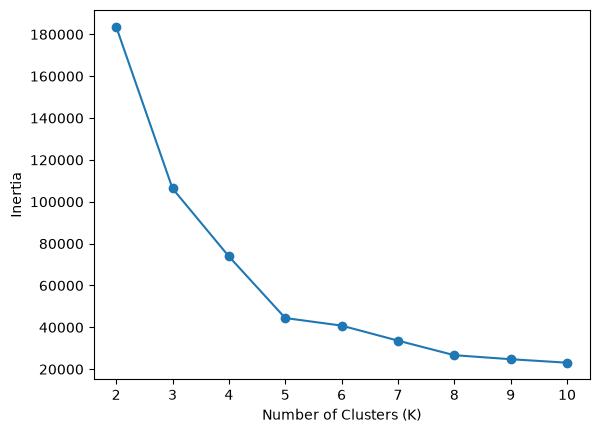

In [22]:
df = pd.read_csv("train.csv")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)

    inertia.append(model.inertia_)

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

# plt.scatter(
#     X["Annual Income (k$)"],
#     X["Spending Score (1-100)"],
#     c=model.labels_
# )

# plt.xlabel("Annual Income (k$)")
# plt.ylabel("Spending Score (1-100)")

# plt.show()

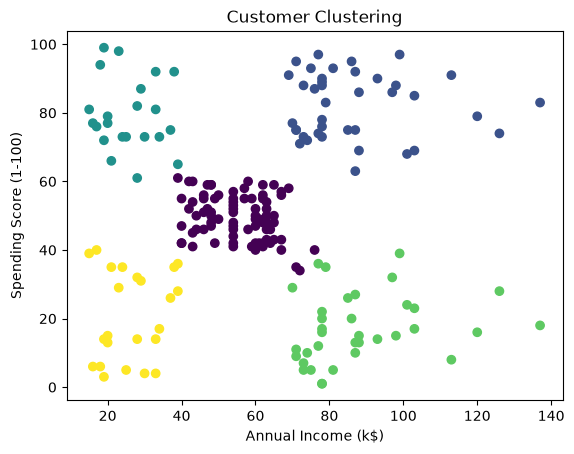

In [24]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=5,
    random_state=42
)

labels = model.fit_predict(X)

df["Cluster"] = labels

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=labels
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clustering")

plt.show()

In [25]:
cluster_mean = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print(cluster_mean)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3956
K=3, Silhouette Score=0.4676
K=4, Silhouette Score=0.4938
K=5, Silhouette Score=0.5539
K=6, Silhouette Score=0.5128
K=7, Silhouette Score=0.5017
K=8, Silhouette Score=0.4963
K=9, Silhouette Score=0.4559
K=10, Silhouette Score=0.4426


In [27]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [32]:
model_unscaled = KMeans(n_clusters=5, random_state=42)
labels_unscaled = model_unscaled.fit_predict(X)

df["Cluster_Unscaled"] = labels_unscaled

cluster_unscaled = df.groupby("Cluster_Unscaled")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()

cluster_unscaled

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_Unscaled,,,
0,46.213483,47.719101,41.797753
1,32.454545,108.181818,82.727273
2,24.689655,29.586207,73.655172
3,40.394737,87.000000,18.631579
4,31.787879,76.090909,77.757576


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model_scaled = KMeans(n_clusters=5, random_state=42)

labels_scaled = model_scaled.fit_predict(X_scaled)

df["Cluster_Scaled"] = labels_scaled

cluster_scaled = df.groupby("Cluster_Scaled")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

cluster_scaled

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_Scaled,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


In [37]:
from sklearn.metrics import silhouette_score

score_unscaled = silhouette_score(
    X,
    labels_unscaled
)

score_scaled = silhouette_score(
    X_scaled,
    labels_scaled
)

print(f"스케일링 전: {score_unscaled:.4f}")
print(f"스케일링 후: {score_scaled:.4f}")

스케일링 전: 0.3576
스케일링 후: 0.4085


In [43]:
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")


K=2, Silhouette Score=0.3355
K=3, Silhouette Score=0.3579
K=4, Silhouette Score=0.4040
K=5, Silhouette Score=0.4085
K=6, Silhouette Score=0.4311
K=7, Silhouette Score=0.4101
K=8, Silhouette Score=0.3674
K=9, Silhouette Score=0.3744
K=10, Silhouette Score=0.3619


In [44]:
model = KMeans(
    n_clusters=6,
    random_state=42
)

labels = model.fit_predict(X_scaled)

df["Cluster"] = labels

cluster_mean = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print(cluster_mean)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        56.333333           54.266667               49.066667
1        32.692308           86.538462               82.128205
2        25.560000           26.480000               76.240000
3        26.125000           59.425000               44.450000
4        44.000000           90.133333               17.933333
5        45.523810           26.285714               19.380952


(200, 2)
설명된 분산 비율:
[0.44266167 0.33308378]

총 설명된 분산 비율:
0.7757454566976747


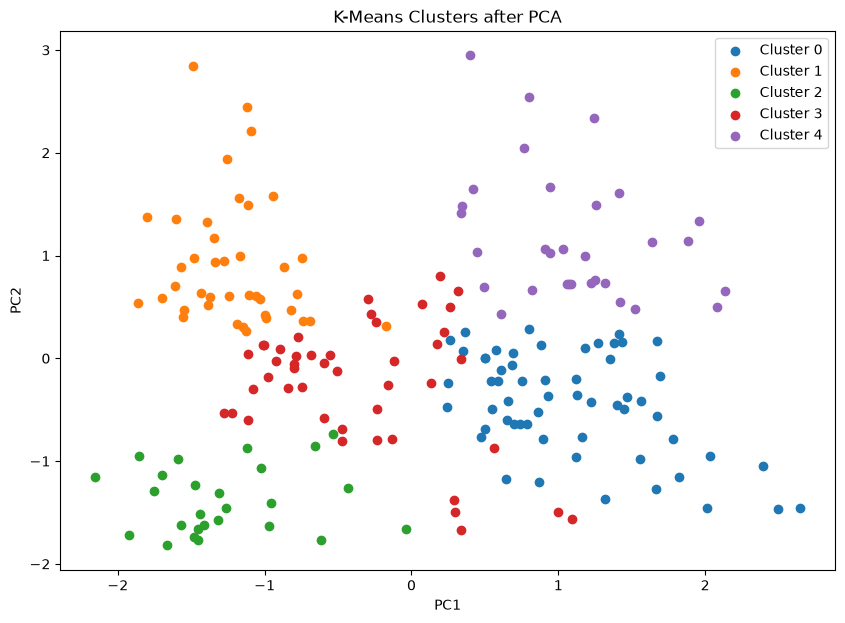

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print("설명된 분산 비율:")
print(pca.explained_variance_ratio_)

print()

print("총 설명된 분산 비율:")
print(pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = labels_scaled

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters after PCA")
plt.legend()
plt.show()

### Online Retail Data - KMeans

In [51]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [53]:
print(df.shape)
print(df.head)
print(df.info())

(541909, 8)
<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitP

In [54]:
print(df["Quantity"].describe())
print((df["Quantity"] < 0).sum())

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64
10624


In [56]:
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print(cancelled.shape)
print(cancelled.head())
print(
    cancelled["Quantity"].describe()
)

(9288, 8)
    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

            InvoiceDate  UnitPrice  CustomerID         Country  
141 2010-12-01 09:41:00      27.50     14527.0  United Kingdom  
154 2010-12-01 09:49:00       4.65     15311.0  United Kingdom  
235 2010-12-01 10:24:00       1.65     17548.0  United Kingdom  
236 2010-12-01 10:24:00       0.29     17548.0  United Kingdom  
237 2010-12-01 10:24:00       0.29     17548.0  United Kingdom  
count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.0000

In [57]:
df_clean = df[df["CustomerID"].notna() & ~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

print("원본 : ", df.shape)
print("정제 후 : ", df_clean.shape)

원본 :  (541909, 8)
정제 후 :  (397924, 8)


In [58]:
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()

print(frequency)

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4339, dtype: int64


In [61]:
df_clean["TotalPrice"] = (df_clean["Quantity"] * df_clean["UnitPrice"])


In [62]:
monetary = df_clean.groupby("CustomerID")["TotalPrice"].sum()

print(monetary.head())
print(monetary.describe())

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: TotalPrice, dtype: float64
count      4339.000000
mean       2053.793018
std        8988.248381
min           0.000000
25%         307.245000
50%         674.450000
75%        1661.640000
max      280206.020000
Name: TotalPrice, dtype: float64


In [63]:
print(df_clean["InvoiceDate"].max())

2011-12-09 12:50:00


In [65]:
snapshot_date = df_clean["InvoiceDate"].max()

recency = df_clean.groupby("CustomerID")["InvoiceDate"].max()
recency = (snapshot_date - df_clean.groupby("CustomerID")["InvoiceDate"].max()).dt.days

recency

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
          ... 
18280.0    277
18281.0    180
18282.0      7
18283.0      3
18287.0     42
Name: InvoiceDate, Length: 4339, dtype: int64

In [66]:
rfm = pd.concat([recency, frequency, monetary], axis=1)

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          1  77183.60
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40


In [67]:
print(rfm.describe())
print(rfm.skew())

           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     91.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       0.000000     1.000000       0.000000
25%      17.000000     1.000000     307.245000
50%      50.000000     2.000000     674.450000
75%     141.000000     5.000000    1661.640000
max     373.000000   210.000000  280206.020000
Recency       1.246357
Frequency    12.100028
Monetary     19.326985
dtype: float64


In [69]:
import numpy as np

rfm_log = np.log1p(rfm)
print("변환 전 : ", rfm.skew())

print("변환 후 : ", rfm_log.skew())

변환 전 :  Recency       1.246357
Frequency    12.100028
Monetary     19.326985
dtype: float64
변환 후 :  Recency     -0.554079
Frequency    1.208917
Monetary     0.360562
dtype: float64


In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

print(X_scaled.shape)

scaled_df = pd.DataFrame(X_scaled, columns=["Recency", "Frequency", "Monetary"])

print(scaled_df.describe())

(4339, 3)
            Recency     Frequency      Monetary
count  4.339000e+03  4.339000e+03  4.339000e+03
mean  -1.981463e-16  1.965087e-17  1.375561e-16
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -2.630378e+00 -9.550131e-01 -5.226583e+00
25%   -6.122687e-01 -9.550131e-01 -6.828165e-01
50%    1.148932e-01 -3.614119e-01 -6.083446e-02
75%    8.298694e-01  6.533562e-01  6.533554e-01
max    1.506044e+00  5.865344e+00  4.718418e+00


K=2, Inertia=6511.38
K=2, Silhouette Score=0.4344
K=3, Inertia=4904.19
K=3, Silhouette Score=0.3390
K=4, Inertia=4001.17
K=4, Silhouette Score=0.3352
K=5, Inertia=3385.81
K=5, Silhouette Score=0.3147
K=6, Inertia=2910.41
K=6, Silhouette Score=0.3138
K=7, Inertia=2625.55
K=7, Silhouette Score=0.2916
K=8, Inertia=2393.18
K=8, Silhouette Score=0.2907
K=9, Inertia=2215.40
K=9, Silhouette Score=0.2930
K=10, Inertia=2048.11
K=10, Silhouette Score=0.2773


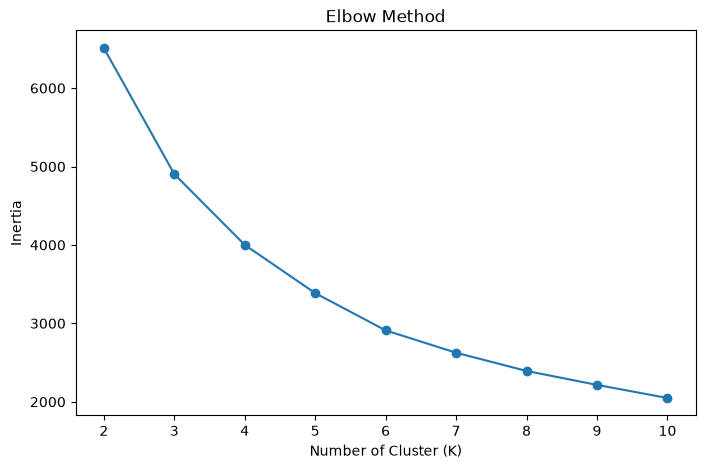

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


inertia = []
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    model.fit(X_scaled)

    inertia.append(model.inertia_)
    labels = model.predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Inertia={model.inertia_:.2f}")
    print(
        f"K={k}, "
        f"Silhouette Score={score:.4f}"
    )

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()



In [77]:
model = KMeans(n_clusters=2, random_state=42, n_init=10)

labels = model.fit_predict(X_scaled)

rfm["Cluster"] = labels
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_summary)
print(rfm["Cluster"].value_counts().sort_index())

            Recency  Frequency     Monetary
Cluster                                    
0        132.481592   1.680179   500.757082
1         24.760606   8.495758  4584.770976
Cluster
0    2689
1    1650
Name: count, dtype: int64


In [78]:
model_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)

labels_k4 = model_k4.fit_predict(X_scaled)

rfm["Cluster_K4"] = labels_k4

cluster_k4 = rfm.groupby("Cluster_K4")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_k4)

print(rfm["Cluster_K4"].value_counts().sort_index())

               Recency  Frequency     Monetary
Cluster_K4                                    
0            10.349854  13.978134  8293.131356
1           179.355407   1.320170   350.783251
2            67.498749   4.226022  1838.547417
3            17.138614   2.112624   545.188379
Cluster_K4
0     686
1    1646
2    1199
3     808
Name: count, dtype: int64


PCA 결과 shape :  (4339, 2)
PC1 설명된 분산 비율 :  0.7501832408569364
PC2 설명된 분산 비율 :  0.18817824706255604
총 설명된 분산 비율  :  0.9383614879194925
      Recency  frequency  monetary
PC1 -0.512049   0.618373  0.596172
PC2  0.848779   0.257736  0.461678
        PC1       PC2  Cluster
0  0.890938  2.657194        2
1  2.603385 -0.894492        0
2  0.468820  0.756012        2
3  0.119649 -0.411611        3
4 -1.661790  0.636593        1


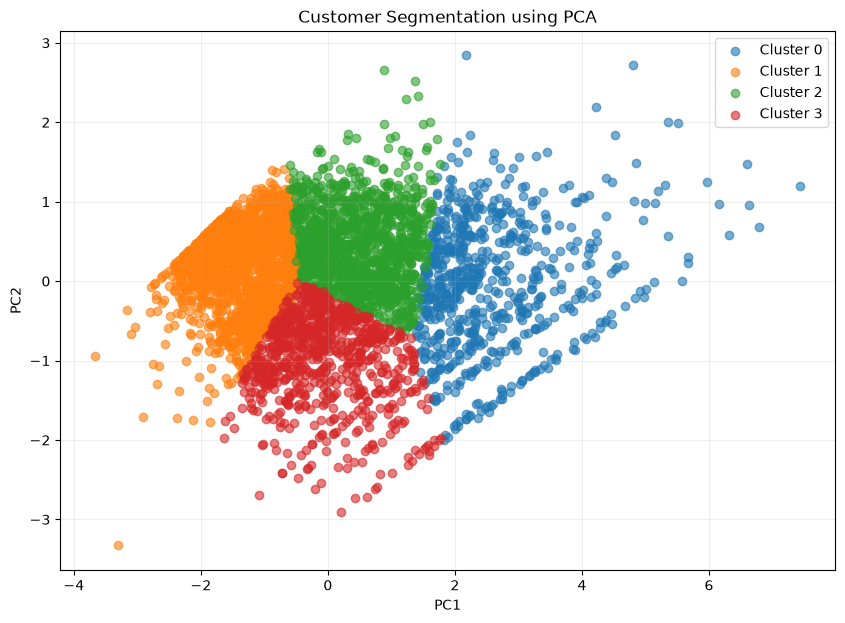

In [83]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA 결과 shape : ", X_pca.shape)

print("PC1 설명된 분산 비율 : ", pca.explained_variance_ratio_[0])
print("PC2 설명된 분산 비율 : ", pca.explained_variance_ratio_[1])

print("총 설명된 분산 비율  : ", pca.explained_variance_ratio_.sum())

pca_components = pd.DataFrame(pca.components_, columns=["Recency", "frequency", "monetary"], index=["PC1", "PC2"])

print(pca_components)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = labels_k4

print(pca_df.head())

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using PCA")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

PCA 설명된 분산 비율
[0.75018324 0.18817825]

총 설명된 분산 비율: 0.9383614879194925

K-Means 중심점 - StandardScaler 공간
[[-1.31185611  1.68034966  1.41243151]
 [ 0.85862327 -0.77500497 -0.78396313]
 [ 0.11903847  0.36603164  0.5428369 ]
 [-0.81535025 -0.38421529 -0.40048618]]

K-Means 중심점 - PCA 공간
[[ 2.55286905 -0.02830095]
 [-1.38627593  0.16709624]
 [ 0.48901464  0.44599268]
 [-0.05884771 -0.97597379]]


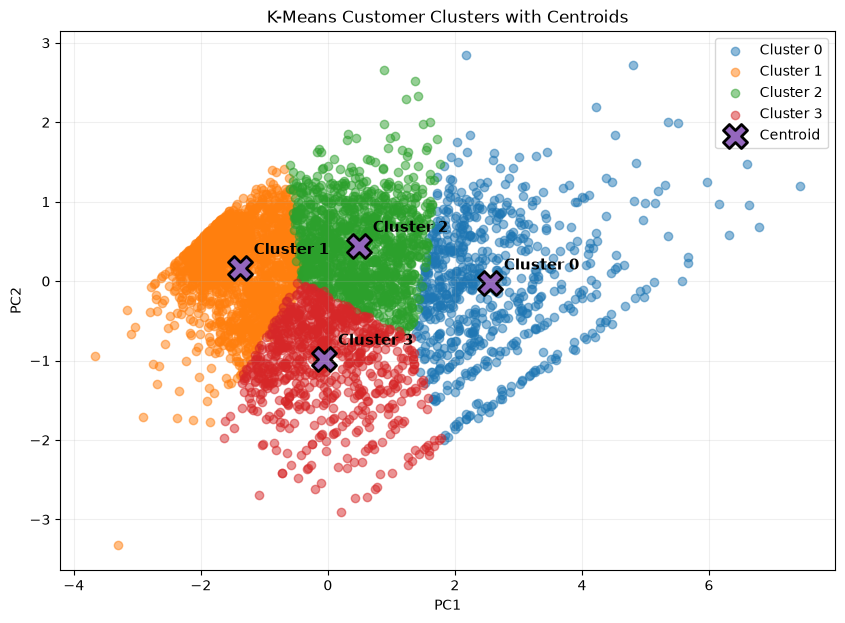

        PC1       PC2  Cluster     Recency  Frequency     Monetary
0  2.552869 -0.028301        0  132.481592   1.680179   500.757082
1 -1.386276  0.167096        1   24.760606   8.495758  4584.770976


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ============================================================
# 1. K-Means K=4
# ============================================================

model_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_k4 = model_k4.fit_predict(X_scaled)

rfm["Cluster"] = labels_k4


# ============================================================
# 2. PCA
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = labels_k4


# ============================================================
# 3. PCA 설명된 분산 확인
# ============================================================

print("PCA 설명된 분산 비율")
print(
    pca.explained_variance_ratio_
)

print()

print(
    "총 설명된 분산 비율:",
    pca.explained_variance_ratio_.sum()
)


# ============================================================
# 4. K-Means의 중심점
# ============================================================

# K-Means 중심점은 X_scaled 공간에 존재
centers_scaled = model_k4.cluster_centers_

print()
print("K-Means 중심점 - StandardScaler 공간")
print(centers_scaled)


# ============================================================
# 5. 중심점을 PCA 공간으로 변환
# ============================================================

centers_pca = pca.transform(
    centers_scaled
)

print()
print("K-Means 중심점 - PCA 공간")
print(centers_pca)


# ============================================================
# 6. PCA 그래프
# ============================================================

plt.figure(figsize=(10, 7))

# 고객 데이터
for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )


# 군집 중심점
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=2,
    label="Centroid"
)


# 중심점에 군집 번호 표시
for cluster, (pc1, pc2) in enumerate(centers_pca):

    plt.annotate(
        f"Cluster {cluster}",
        (pc1, pc2),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-Means Customer Clusters with Centroids"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

centroid_df = pd.DataFrame(
    centers_pca,
    columns=["PC1", "PC2"]
)

centroid_df["Cluster"] = range(4)

centroid_df = centroid_df.merge(
    cluster_summary,
    left_on="Cluster",
    right_index=True
)

print(centroid_df)

            Recency  Frequency     Monetary
Cluster                                    
0         10.349854  13.978134  8293.131356
1        179.355407   1.320170   350.783251
2         67.498749   4.226022  1838.547417
3         17.138614   2.112624   545.188379


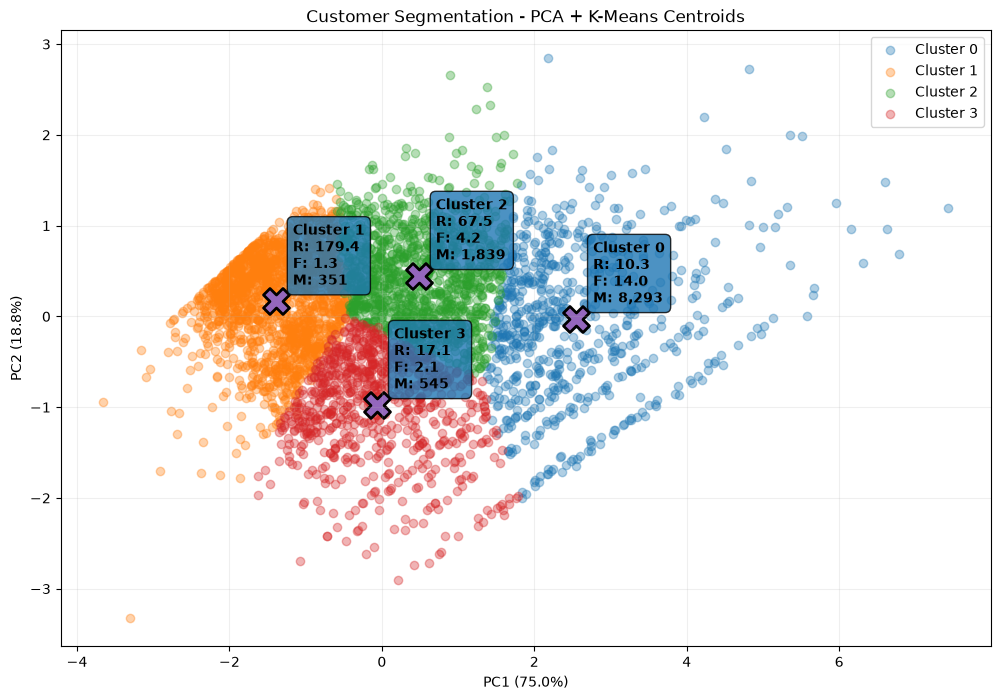

In [87]:
cluster_summary = rfm.groupby(
    "Cluster"
)[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].mean()

print(cluster_summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 고객 데이터
for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        alpha=0.35,
        label=f"Cluster {cluster}"
    )


# 중심점
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=350,
    edgecolors="black",
    linewidths=2
)


# 중심점에 군집 정보 표시
for cluster, (pc1, pc2) in enumerate(centers_pca):

    recency = cluster_summary.loc[
        cluster,
        "Recency"
    ]

    frequency = cluster_summary.loc[
        cluster,
        "Frequency"
    ]

    monetary = cluster_summary.loc[
        cluster,
        "Monetary"
    ]

    text = (
        f"Cluster {cluster}\n"
        f"R: {recency:.1f}\n"
        f"F: {frequency:.1f}\n"
        f"M: {monetary:,.0f}"
    )

    plt.annotate(
        text,
        (pc1, pc2),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.8
        )
    )


plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)

plt.title(
    "Customer Segmentation - PCA + K-Means Centroids"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()